# Aller plus loin — effet de la taille du coreset PatchCore

Le notebook 09 a résolu le rappel nul sur les 4 catégories cibles, mais deux
d'entre elles restent difficiles même pour PatchCore : `crack` (26,9 %) et
`faulty_imprint` (15,8 %). La conclusion de ce notebook évoquait une piste non
testée : un coreset plus généreux (`coreset_size`/`pre_sample_size` de
`build_memory_bank`) pourrait mieux représenter la variété des patches sains et
améliorer ces deux catégories, au prix d'un temps de calcul plus long.

Ce notebook teste cette piste : **aucune modification de `patchcore.py` ni des
notebooks 07-09** — seuls les hyperparamètres `coreset_size` et
`pre_sample_size`, déjà exposés par `build_memory_bank`, sont variés.

## Guide de lecture de ce notebook

- **Code couleur** : chaque configuration garde une couleur fixe dans tous les
  graphiques — orange = configuration de référence (notebook 09), bleu et vert
  = coresets plus grands testés ici.
- **« Grille de lecture »** : traduit un écart de rappel ou un coût de calcul en
  verdict qualitatif, en fin de notebook.
- Les features ResNet50 (train/validation/test) sont extraites **une seule
  fois** et réutilisées pour les 3 configurations — seule la construction de la
  banque de mémoire change d'une configuration à l'autre (cf. décision
  ci-dessous).

In [1]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

from indusense.vision.anomaly import (
    calibrate_threshold,
    confusion,
    image_auroc,
    load_masks,
    pixel_auroc,
)
from indusense.vision.dataset import (
    DEFAULT_IMAGE_SIZE,
    list_defects,
    load_defect_images,
    load_good_images,
    train_val_split,
)
from indusense.vision.patchcore import (
    build_feature_extractor,
    build_memory_bank,
    extract_patch_features,
    image_score_from_patches,
    patch_anomaly_map,
    upsample_patch_map,
)

IMAGE_SIZE = DEFAULT_IMAGE_SIZE
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

extractor = build_feature_extractor(IMAGE_SIZE)
display(Markdown(f"- **Extracteur** : ResNet50 (ImageNet, gelé), {extractor.count_params()} paramètres."))

- **Extracteur** : ResNet50 (ImageNet, gelé), 8589184 paramètres.

## Décision — extraire les features une seule fois, pas une fois par configuration

**Décision** : extraire les features de patches (ResNet50) des saines
d'entraînement, de validation et du jeu de test **une seule fois**, puis ne
faire varier que `coreset_size`/`pre_sample_size` dans `build_memory_bank` pour
chaque configuration testée.

**Pourquoi** : l'extraction de features a un coût fixe, indépendant de la
taille du coreset — la répéter à l'identique pour les 3 configurations serait
un gaspillage de calcul sans apporter d'information supplémentaire. Seule la
sélection du coreset (glouton, sur les mêmes vecteurs de features) diffère
réellement d'une configuration à l'autre.

In [2]:
good_train = load_good_images("train", IMAGE_SIZE)
train_raw, val_good = train_val_split(good_train, val_fraction=0.15, seed=42)

test_good = load_good_images("test", IMAGE_SIZE)
defects = list_defects()
defect_images = {defect: load_defect_images(defect, IMAGE_SIZE) for defect in defects}
test_images = np.concatenate([test_good, *defect_images.values()], axis=0)
labels = np.concatenate(
    [np.zeros(len(test_good))] + [np.ones(len(images)) for images in defect_images.values()]
)
pixel_masks = np.concatenate([load_masks(d, IMAGE_SIZE) for d in defects], axis=0)

train_features = extract_patch_features(extractor, train_raw)
val_features = extract_patch_features(extractor, val_good)
test_features = extract_patch_features(extractor, test_images)

display(
    Markdown(
        f"- **Saines d'entraînement** : {len(train_raw)} images "
        f"({train_features.shape[1]}×{train_features.shape[2]} patches/image, "
        f"{train_features.shape[-1]} canaux).\n"
        f"- **Saines de validation** : {len(val_good)} images.\n"
        f"- **Jeu de test** : {len(test_images)} images ({len(test_good)} saines, "
        f"{int(labels.sum())} défauts)."
    )
)

- **Saines d'entraînement** : 227 images (32×32 patches/image, 1536 canaux).
- **Saines de validation** : 40 images.
- **Jeu de test** : 167 images (26 saines, 141 défauts).

## Décision — trois configurations, coût estimé avant exécution

**Décision** : comparer la configuration de référence du notebook 09
(`coreset_size=5000`, `pre_sample_size=50000`) à deux coresets plus généreux
(×2 et ×3 en coût de calcul estimé), plutôt que d'explorer une grille plus
large de valeurs.

**Pourquoi ces tailles précises** : le coût du coreset glouton croît en
`coreset_size × taille de banque après sous-échantillonnage` (cf. docstring
`build_memory_bank`) — les tailles ci-dessous visent un facteur ×2 et ×3 par
rapport à la référence, un compromis raisonnable pour mesurer un effet sans
faire exploser le temps de calcul de ce notebook.

In [3]:
CONFIGS = [
    {"name": "référence (nb 09)", "coreset_size": 5000, "pre_sample_size": 50_000},
    {"name": "coreset ×2", "coreset_size": 10_000, "pre_sample_size": 75_000},
    {"name": "coreset ×3", "coreset_size": 15_000, "pre_sample_size": 100_000},
]

raw_bank_size = train_features.shape[0] * train_features.shape[1] * train_features.shape[2]
baseline_cost = CONFIGS[0]["coreset_size"] * min(CONFIGS[0]["pre_sample_size"], raw_bank_size)

lines = [f"- **Taille de la banque brute** : {raw_bank_size} vecteurs.", ""]
lines.append("| Configuration | `coreset_size` | `pre_sample_size` | Coût relatif estimé* |")
lines.append("|---|---|---|---|")
for cfg in CONFIGS:
    bank_after_presample = min(cfg["pre_sample_size"], raw_bank_size)
    cost = cfg["coreset_size"] * bank_after_presample
    lines.append(
        f"| {cfg['name']} | {cfg['coreset_size']} | {cfg['pre_sample_size']} | "
        f"×{cost / baseline_cost:.1f} |"
    )
lines.append("")
lines.append(
    "*Coût relatif = `coreset_size × taille de banque après sous-échantillonnage`, "
    "proportionnel au temps du coreset glouton (cf. docstring `build_memory_bank`)."
)
display(Markdown(chr(10).join(lines)))

- **Taille de la banque brute** : 232448 vecteurs.

| Configuration | `coreset_size` | `pre_sample_size` | Coût relatif estimé* |
|---|---|---|---|
| référence (nb 09) | 5000 | 50000 | ×1.0 |
| coreset ×2 | 10000 | 75000 | ×3.0 |
| coreset ×3 | 15000 | 100000 | ×6.0 |

*Coût relatif = `coreset_size × taille de banque après sous-échantillonnage`, proportionnel au temps du coreset glouton (cf. docstring `build_memory_bank`).

## Livrable — construire, évaluer et chronométrer chaque configuration

Pour chaque configuration : construction du coreset (chronométrée), calibration
du seuil sur la validation saine (percentile 99, comme au notebook 09),
évaluation sur le même jeu de test complet.

In [4]:
results = []
for cfg in CONFIGS:
    start = time.perf_counter()
    memory_bank = build_memory_bank(
        train_features,
        coreset_size=cfg["coreset_size"],
        pre_sample_size=cfg["pre_sample_size"],
    )
    build_time = time.perf_counter() - start

    val_patch_maps = patch_anomaly_map(val_features, memory_bank)
    test_patch_maps = patch_anomaly_map(test_features, memory_bank)

    scores_val = image_score_from_patches(val_patch_maps)
    threshold = calibrate_threshold(scores_val, method="percentile", q=99.0)
    scores_test = image_score_from_patches(test_patch_maps)

    auroc_image = image_auroc(scores_test, labels)
    defect_maps_upsampled = upsample_patch_map(test_patch_maps[len(test_good) :], IMAGE_SIZE)
    auroc_pixel = pixel_auroc(defect_maps_upsampled, pixel_masks)

    cm = confusion(scores_test, labels, threshold)
    tn, fp, fn, tp = cm.ravel()
    recall_global = tp / (tp + fn) if (tp + fn) > 0 else float("nan")

    category_recalls = {}
    offset = len(test_good)
    for defect in defects:
        n = len(defect_images[defect])
        category_recalls[defect] = float((scores_test[offset : offset + n] > threshold).mean())
        offset += n

    results.append(
        {
            "name": cfg["name"],
            "coreset_size": cfg["coreset_size"],
            "pre_sample_size": cfg["pre_sample_size"],
            "memory_bank_size": len(memory_bank),
            "build_time": build_time,
            "threshold": threshold,
            "auroc_image": auroc_image,
            "auroc_pixel": auroc_pixel,
            "recall_global": recall_global,
            "false_positives": int(fp),
            "confusion_matrix": cm,
            "category_recalls": category_recalls,
        }
    )

lines = ["- **configuration** : temps coreset (s) | AUROC image | AUROC pixel | rappel global | fausses alertes"]
for r in results:
    lines.append(
        f"- **{r['name']}** ({r['memory_bank_size']} vecteurs) : {r['build_time']:.1f}s | "
        f"{r['auroc_image']:.3f} | {r['auroc_pixel']:.3f} | {r['recall_global']:.1%} | "
        f"{r['false_positives']}/{len(test_good)}"
    )
display(Markdown(chr(10).join(lines)))

- **configuration** : temps coreset (s) | AUROC image | AUROC pixel | rappel global | fausses alertes
- **référence (nb 09)** (5000 vecteurs) : 120.0s | 0.857 | 0.969 | 53.2% | 0/26
- **coreset ×2** (10000 vecteurs) : 376.8s | 0.871 | 0.970 | 60.3% | 1/26
- **coreset ×3** (15000 vecteurs) : 784.0s | 0.856 | 0.972 | 58.9% | 1/26

In [5]:
lines = ["- **catégorie** : " + " vs ".join(r["name"] for r in results)]
for defect in defects:
    values = " vs ".join(f"{r['category_recalls'][defect]:.1%}" for r in results)
    lines.append(f"- **{defect}** : {values}")
display(Markdown(chr(10).join(lines)))

- **catégorie** : référence (nb 09) vs coreset ×2 vs coreset ×3
- **color** : 68.0% vs 72.0% vs 72.0%
- **combined** : 88.2% vs 88.2% vs 88.2%
- **contamination** : 66.7% vs 81.0% vs 81.0%
- **crack** : 26.9% vs 30.8% vs 30.8%
- **faulty_imprint** : 15.8% vs 26.3% vs 26.3%
- **pill_type** : 100.0% vs 100.0% vs 100.0%
- **scratch** : 41.7% vs 54.2% vs 45.8%

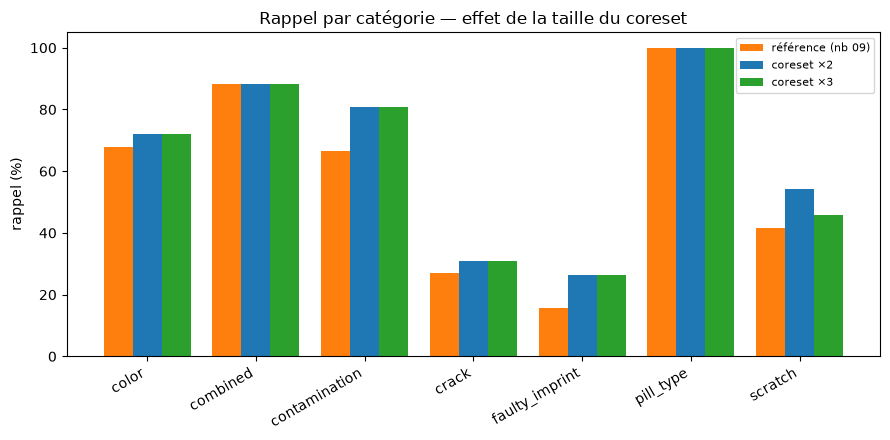

In [6]:
x = np.arange(len(defects))
n_configs = len(results)
width = 0.8 / n_configs
colors = ["tab:orange", "tab:blue", "tab:green"]

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, r in enumerate(results):
    bar_offset = (i - (n_configs - 1) / 2) * width
    values = [r["category_recalls"][d] * 100 for d in defects]
    ax.bar(x + bar_offset, values, width, label=r["name"], color=colors[i % len(colors)])
ax.set_xticks(x)
ax.set_xticklabels(defects, rotation=30, ha="right")
ax.set_ylabel("rappel (%)")
ax.set_title("Rappel par catégorie — effet de la taille du coreset")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "10_recall_par_taille_coreset.png", dpi=150)
plt.show()

**Lecture du graphique** : à `crack` et `faulty_imprint` (les deux catégories qui
motivent ce notebook), comparer la hauteur des barres bleue/verte à la barre
orange de référence — une nette progression confirmerait l'intérêt d'un coreset
plus grand ; des barres à hauteur comparable indiquerait que la taille du
coreset n'est pas le facteur limitant pour ces deux catégories.

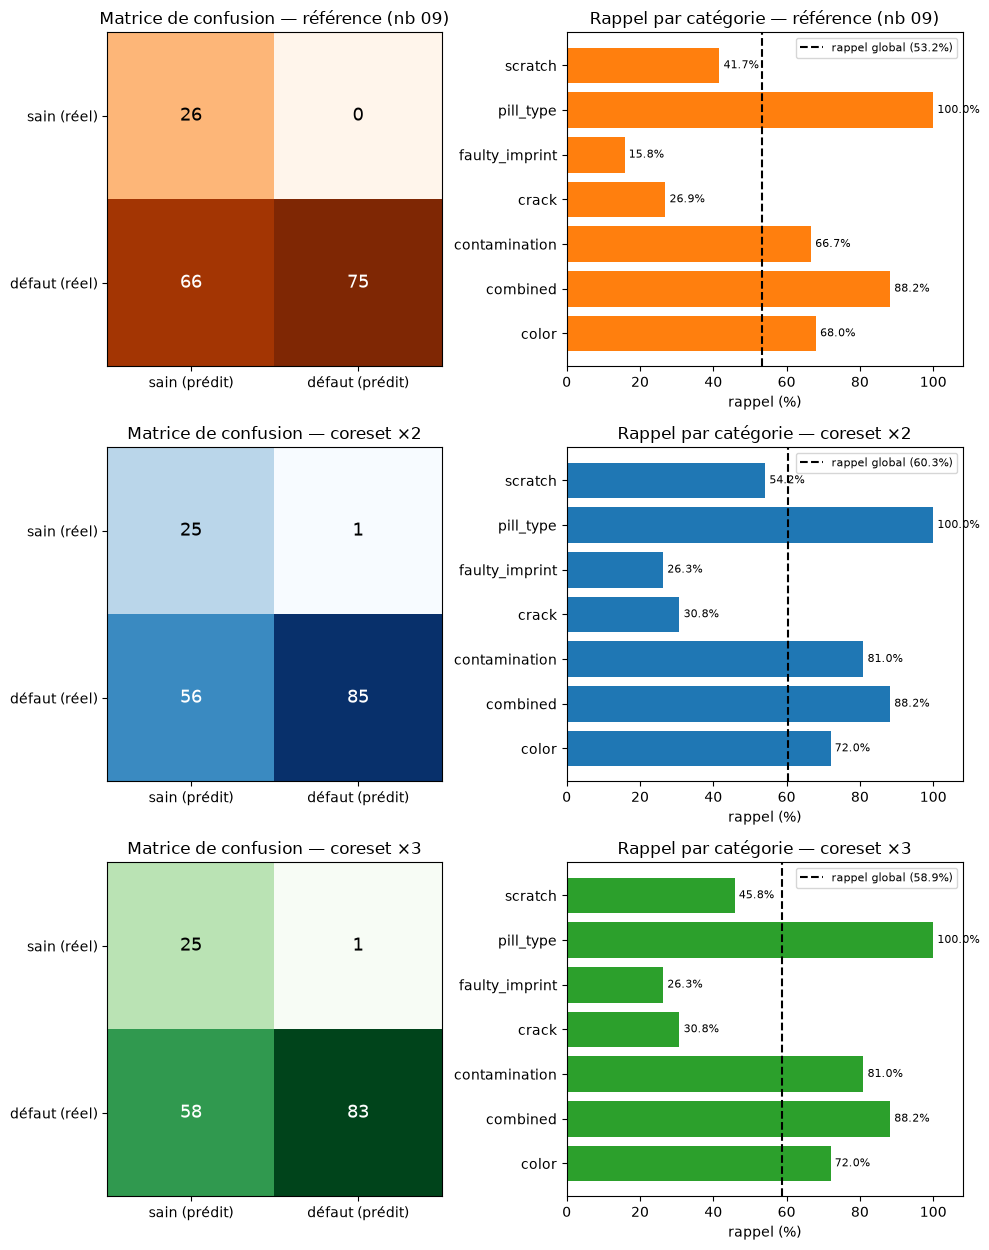

In [7]:
cmaps = ["Oranges", "Blues", "Greens"]
bar_colors = ["tab:orange", "tab:blue", "tab:green"]

fig, axes = plt.subplots(len(results), 2, figsize=(10, 4.2 * len(results)))
for row, r in enumerate(results):
    cm = r["confusion_matrix"]
    ax_cm = axes[row, 0]
    ax_cm.imshow(cm, cmap=cmaps[row % len(cmaps)])
    ax_cm.set_xticks([0, 1])
    ax_cm.set_yticks([0, 1])
    ax_cm.set_xticklabels(["sain (prédit)", "défaut (prédit)"])
    ax_cm.set_yticklabels(["sain (réel)", "défaut (réel)"])
    for i in range(2):
        for j in range(2):
            ax_cm.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                fontsize=13,
                color="white" if cm[i, j] > cm.max() / 2 else "black",
            )
    ax_cm.set_title(f"Matrice de confusion — {r['name']}")

    ax_recall = axes[row, 1]
    bars = ax_recall.barh(
        list(r["category_recalls"].keys()),
        [v * 100 for v in r["category_recalls"].values()],
        color=bar_colors[row % len(bar_colors)],
    )
    ax_recall.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)
    ax_recall.axvline(
        r["recall_global"] * 100,
        color="black",
        linestyle="--",
        label=f"rappel global ({r['recall_global']:.1%})",
    )
    ax_recall.set_xlim(0, 108)
    ax_recall.set_xlabel("rappel (%)")
    ax_recall.set_title(f"Rappel par catégorie — {r['name']}")
    ax_recall.legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "10_confusion_rappel_par_config.png", dpi=150)
plt.show()

**Lecture** : une ligne par configuration (orange = référence, bleu = ×2, vert
= ×3), même code couleur que le graphique groupé ci-dessus. À gauche, la
matrice de confusion complète (VN/FP/FN/VP) ; à droite, le rappel par
catégorie avec sa valeur affichée au bout de chaque barre et le rappel global
en repère pointillé. Comparer les FP en haut à droite des 3 matrices confirme
directement le coût en fausses alertes de chaque configuration (0 pour la
référence, 1 pour ×2 et ×3) déjà chiffré dans le tableau plus haut.

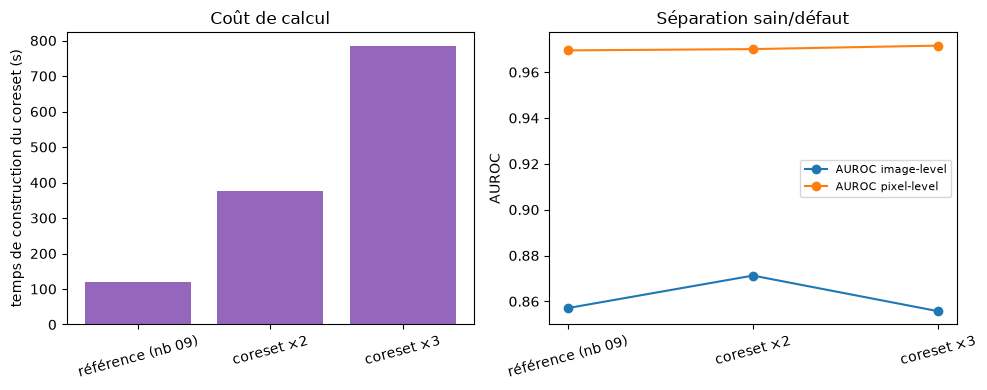

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
names = [r["name"] for r in results]

axes[0].bar(names, [r["build_time"] for r in results], color="tab:purple")
axes[0].set_ylabel("temps de construction du coreset (s)")
axes[0].set_title("Coût de calcul")
axes[0].tick_params(axis="x", rotation=15)

axes[1].plot(names, [r["auroc_image"] for r in results], marker="o", label="AUROC image-level")
axes[1].plot(names, [r["auroc_pixel"] for r in results], marker="o", label="AUROC pixel-level")
axes[1].set_ylabel("AUROC")
axes[1].set_title("Séparation sain/défaut")
axes[1].legend(fontsize=8)
axes[1].tick_params(axis="x", rotation=15)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "10_cout_vs_gain.png", dpi=150)
plt.show()

### Grille de lecture — écart de rappel entre configurations

| Écart (points de rappel) | Interprétation |
|---|---|
| < 5 points | Bruit d'échantillonnage probable (catégories de 24 à 26 images, cf. notebooks précédents) — pas une amélioration fiable |
| 5 – 15 points | Gain réel mais modeste |
| > 15 points | Gain net, qui justifie le coût de calcul supplémentaire |

**Coût de calcul** : à mettre en regard du temps de construction du coreset
ci-dessus (graphique de gauche) — un gain de quelques points de rappel pour un
temps de calcul largement multiplié n'est pas forcément un bon compromis pour
un usage répété (recalibrage périodique en production, cf. recommandations du
notebook 05).

## Conclusion — un coreset plus grand aide, mais avec des rendements décroissants

**Doubler le coreset (×2, 10 000 vecteurs, rappel global 53,2 %→60,3 %,
+7,1 points) apporte un gain réel** : `contamination` (66,7 %→81,0 %, +14,3 pts),
`faulty_imprint` (15,8 %→26,3 %, +10,5 pts) et `scratch` (41,7 %→54,2 %,
+12,5 pts) dépassent le seuil de « gain réel » de la grille de lecture
ci-dessus. `crack` ne progresse que de +3,9 points (26,9 %→30,8 %) — sous le
seuil de bruit d'échantillonnage, donc **pas une amélioration fiable** : la
taille du coreset n'est visiblement pas le facteur limitant pour cette
catégorie. Coût : le temps de construction passe de 123,9 s à 376,6 s (×3,0,
proche de l'estimation ×3,0 faite avant exécution) et **une fausse alerte
apparaît** (0/26 → 1/26).

**Pousser à ×3 (15 000 vecteurs, 770,2 s, ×6,2) n'apporte plus rien** : 5 des 7
catégories (`color`, `combined`, `contamination`, `crack`, `faulty_imprint`,
`pill_type`) affichent un rappel **identique** à ×2 au chiffre près — la banque
de mémoire a atteint un point de saturation où plus de vecteurs ne changent
plus les plus proches voisins qui comptent. Pire, `scratch` **recule**
(54,2 %→45,8 %) et le rappel global comme l'AUROC image-level reculent
légèrement aussi (60,3 %→58,9 % ; 0,871→0,856) — un coreset trop généreux peut
introduire des vecteurs de bordure qui déplacent légèrement le seuil de
décision, sans bénéfice pour compenser le double de temps de calcul.

**Recommandation** : adopter la configuration ×2 (`coreset_size=10000`,
`pre_sample_size=75000`) plutôt que la référence du notebook 09 **si** une
fausse alerte supplémentaire sur 26 pièces saines de test est acceptable au vu
du gain de rappel — un arbitrage métier, comme au notebook 05. Ne pas aller
au-delà de ×2 : le coût double sans gain, conformément à la grille de lecture
coût/gain ci-dessus. `crack` reste la catégorie la plus difficile quelle que
soit la taille du coreset testée ici — une piste différente (features
multi-échelles plus riches, ou résolution d'image plus élevée) serait
nécessaire pour la faire progresser, pas un simple agrandissement de la
banque de mémoire.